In [65]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import tiktoken
import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

### DEFINING THE MODEL

In [113]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim, eps=1e-5):
    super().__init__()
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))
    self.eps = eps

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False) # divide by n here to be consistent with what was used in GPT2
    x = (x-mean)/torch.sqrt(var + self.eps)
    x = x*self.scale + self.shift
    return x


class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    x = 0.5 * x * (1 + torch.tanh(
          torch.sqrt(torch.tensor(2)/torch.pi) * (x + 0.044715*(x**3))
        ))
    return x


class FeedForward(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    emb_dim = cfg["emb_dim"]
    self.layers = nn.Sequential(
        nn.Linear(emb_dim, 4*emb_dim),
        GELU(),
        nn.Linear(4*emb_dim, emb_dim)
    )

  def forward(self, x):
    return self.layers(x)


class MultiHeadAttention(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    d_in, d_out = cfg["emb_dim"], cfg["emb_dim"]
    context_length = cfg["context_length"]
    dropout = cfg["drop_rate"]
    num_heads = cfg["n_heads"]
    qkv_bias = cfg["qkv_bias"]

    assert(d_out % num_heads == 0)

    self.head_dim = d_out // num_heads
    self.num_heads = num_heads

    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer(
        'mask',
        torch.triu(torch.ones(context_length, context_length), diagonal=1)
    )
    self.projection = nn.Linear(d_out, d_out)

  def forward(self, x):
    # x -> [B, T, d_in]
    B, T, d_in = x.shape

    queries = self.W_query(x)
    keys = self.W_key(x)
    values = self.W_value(x)

    queries = queries.view(B, T, self.num_heads, self.head_dim) # [B, T, NH, HD]
    queries = queries.transpose(1, 2) # [B, NH, T, HD]
    keys = keys.view(B, T, self.num_heads, self.head_dim) # [B, T, NH, HD]
    keys = keys.transpose(1, 2) # [B, NH, T, HD]
    values = values.view(B, T, self.num_heads, self.head_dim)
    values = values.transpose(1, 2) # [B, NH, T, HD]

    attn_scores = queries @ keys.transpose(2, 3) # [B, NH, T, T]
    attn_scores.masked_fill_(self.mask.bool()[:T,:T], -torch.inf)
    attn_weights = torch.softmax(attn_scores/self.head_dim**0.5, dim=-1)
    attn_weights = self.dropout(attn_weights)

    context_vecs = attn_weights @ values # [B, NH, T, HD]
    context_vecs = context_vecs.transpose(1,2).reshape(B, T, -1)
    # Reshape instead of view because view needs contiguous
    # Alternative context_vecs.contiguous().view(B, T, -1)
    context_vecs = self.projection(context_vecs) # [B, T, d_out]
    return context_vecs



class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.attn_block = MultiHeadAttention(cfg)
    self.ffwd = FeedForward(cfg)
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.layer_norm1 = LayerNorm(cfg["emb_dim"])
    self.layer_norm2 = LayerNorm(cfg["emb_dim"])

  def forward(self, x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.attn_block(x)
    x = self.dropout(x)
    x = x + shortcut

    shortcut = x
    x = self.layer_norm2(x)
    x = self.ffwd(x)
    x = self.dropout(x)
    x = x + shortcut

    return x


class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_embedding = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_embedding = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.layer_norm = LayerNorm(cfg["emb_dim"])
    self.transformer_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False) # Weight reused here in Open AI GPT2

  def forward(self, x):
    # x.shape [B, T]
    B, T = x.shape
    token_embd = self.token_embedding(x) # [B, T, E]  E -> emb_dim
    pos_embd = self.pos_embedding(torch.arange(0, T).to(device)) # [T, E]
    x = token_embd + pos_embd # [T, E] broadcasted to [B, T, E] and then add
    x = self.dropout(x)
    x = self.transformer_blocks(x)
    x = self.layer_norm(x)
    x = self.out_head(x)
    return x


In [4]:
def text_to_token_ids(text, tokenizer):
  token_ids = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
  token_ids = torch.tensor(token_ids).unsqueeze(0)
  return token_ids

def token_ids_to_text(token_ids, tokenizer):
  text = tokenizer.decode(token_ids.squeeze(0).tolist())
  return text

def generate_text_simple(input_batch, model, context_length, device, max_tokens=50):
  for _ in range(max_tokens):
    input_batch = input_batch[:, -context_length:]
    input_batch = input_batch.to(device)
    model = model.to(device)
    with torch.no_grad():
      logits = model(input_batch)
    probs = torch.softmax(logits[:,-1,:], dim=-1)
    next = torch.argmax(probs, dim=-1, keepdim=True)
    input_batch = torch.cat([input_batch, next], dim=1)

  return input_batch

In [5]:
GPT_CONFIG_124M = {
  "vocab_size": 50257,
  "context_length": 256, # using a smaller size for testing
  "emb_dim": 768,
  "n_heads": 12,
  "n_layers": 12,
  "drop_rate": 0.1,
  "qkv_bias": False
}

In [ ]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")
input_str = "Every effort moves you"

token_ids = generate_text_simple(
    text_to_token_ids(input_str, tokenizer),
    model,
    context_length=GPT_CONFIG_124M["context_length"],
    device=device,
    max_tokens=10
)

print(f"Output: {token_ids_to_text(token_ids, tokenizer)}")


Output: Every effort moves you arrangement legislation fans Server zipAMS List Walton judiciary folk


### Calculating text generation loss

In [ ]:
# Toy examples

input_1 = torch.tensor(tokenizer.encode("every effort moves"))
input_2 = torch.tensor(tokenizer.encode("I really like"))
inputs = torch.stack([input_1, input_2], dim=0)
print(inputs.shape,'\n',inputs)

target_1 = torch.tensor(tokenizer.encode(" effort moves you"))
print(target_1, tokenizer.decode([3626]), tokenizer.encode("effort")) # "effort" vs " effort"
target_2 = torch.tensor(tokenizer.encode(" really like chocolate"))
targets = torch.stack([target_1, target_2], dim=0)
print(targets.shape,'\n',targets)

torch.Size([2, 3]) 
 tensor([[16833,  3626,  6100],
        [   40,  1107,   588]])
tensor([3626, 6100,  345])  effort [14822, 419]
torch.Size([2, 3]) 
 tensor([[ 3626,  6100,   345],
        [ 1107,   588, 11311]])


In [ ]:
inputs = inputs.to(device)
with torch.no_grad():
  logits = model(inputs)

probs = torch.softmax(logits, dim=-1)
print(probs.shape)

token_ids = torch.argmax(probs, dim=-1, keepdim=True)
print(token_ids, token_ids.shape)

# Compare
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Output batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

torch.Size([2, 3, 50257])
tensor([[[49532],
         [ 3797],
         [44376]],

        [[13690],
         [47663],
         [27596]]], device='cuda:0') torch.Size([2, 3, 1])
Targets batch 1:  effort moves you
Output batch 1:  Nib cat inaction


In [ ]:
# Calculating probs for actual target tokens
torch.set_printoptions(sci_mode=False)

target_probs_1 = probs[0, [0,1,2], targets[0]]
print(f"Target probs 1: {target_probs_1}")
output_probs_1 = probs[0, [0,1,2], token_ids[0].flatten()]
print(f"Output probs 1: {output_probs_1}")

target_probs_2 = probs[1, [0,1,2], targets[1]]
print(f"Target probs 2: {target_probs_2}")
output_probs_2 = probs[1, [0,1,2], token_ids[1].flatten()]
print(f"Output probs 2: {output_probs_2}")


Target probs 1: tensor([0.0000, 0.0000, 0.0000], device='cuda:0')
Output probs 1: tensor([0.0002, 0.0002, 0.0002], device='cuda:0')
Target probs 2: tensor([0.0000, 0.0000, 0.0000], device='cuda:0')
Output probs 2: tensor([0.0002, 0.0002, 0.0003], device='cuda:0')


In [ ]:
# NLL
log_probs = torch.log(torch.cat([target_probs_1, target_probs_2]))
print(f"Log probs: {log_probs}")

avg_log_probs = log_probs.mean()
neg_avg_log_probs = -1. * avg_log_probs
print(f"NLL {neg_avg_log_probs}")

Log probs: tensor([-10.7250, -10.1012, -11.5743, -11.5176, -11.1972, -11.5922],
       device='cuda:0')
NLL 11.117919921875


In [ ]:
# Cross Entropy
print(logits.shape, targets.shape)
targets = targets.to(device)
logits_flatten = logits.flatten(0, 1)
targets_flatten = targets.flatten()
loss = F.cross_entropy(logits_flatten, targets_flatten) # Doesn't work with batch dimension
loss # Same as NLL calculated above

torch.Size([2, 3, 50257]) torch.Size([2, 3])


tensor(11.1179, device='cuda:0')

In [ ]:
# Perplexity
perplexity = torch.exp(loss)
nll_uniform = -torch.log(torch.tensor(1./50257))
print(perplexity, torch.exp(nll_uniform)) # Even bad than uniform distribution

tensor(67367.6328, device='cuda:0') tensor(50257.0156)


### Training and validation data loader and loss calc

In [118]:
!wget https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch02/01_main-chapter-code/the-verdict.txt

--2026-04-17 11:52:51--  https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch02/01_main-chapter-code/the-verdict.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20479 (20K) [text/plain]
Saving to: ‘the-verdict.txt’

the-verdict.txt     100%[===================>]  20.00K  --.-KB/s    in 0s      

2026-04-17 11:52:52 (169 MB/s) - ‘the-verdict.txt’ saved [20479/20479]



In [119]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()

raw_text_length = len(raw_text)
print(f"Total characters: {raw_text_length}")

split_ratio = int(0.9*raw_text_length)
train_data = raw_text[:split_ratio]
val_data = raw_text[split_ratio:]

print(f"Train data len: {len(train_data)} Val data len: {len(val_data)}")

Total characters: 20479
Train data len: 18431 Val data len: 2048


In [120]:
class GPTDatasetV1(Dataset):
  def __init__(self, tokenizer, text, context_length, stride) -> None:
    super().__init__()

    token_ids = tokenizer.encode(text)

    self.X = []
    self.Y = []

    for i in range(0, len(token_ids)-context_length, stride):
      print(i)
      x = torch.tensor(token_ids[i: i+context_length])
      y = torch.tensor(token_ids[i+1: i+context_length+1])

      self.X.append(x)
      self.Y.append(y)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, index):
    return self.X[index], self.Y[index]

def create_dataloader_v1(text, batch_size=4, context_length=256, stride=128, shuffle=True, drop_last=True, num_workers=0):
  tokenizer = tiktoken.get_encoding("gpt2")

  dataset = GPTDatasetV1(tokenizer, text, context_length, stride)
  dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=shuffle,
    drop_last=drop_last,
    num_workers=num_workers
  )

  return dataloader


In [126]:
train_dataloader = create_dataloader_v1(
    train_data,
    batch_size=2,
    context_length=256, #GPT_CONFIG_124M["context_length"],
    stride=256,#GPT_CONFIG_124M["context_length"],
    shuffle=True,
    drop_last=True,
    num_workers=0
)

val_dataloader = create_dataloader_v1(
    val_data,
    batch_size=2,
    context_length=256,#GPT_CONFIG_124M["context_length"],
    stride=256,#GPT_CONFIG_124M["context_length"],
    shuffle=False,
    drop_last=False,
    num_workers=0
)


0
256
512
768
1024
1280
1536
1792
2048
2304
2560
2816
3072
3328
3584
3840
4096
4352
0
256


In [127]:
print("Train dataloader:")
for x, y in train_dataloader:
  print(x.shape, y.shape)

print("Val dataloader:")
for x, y in val_dataloader:
  print(x.shape, y.shape)

Train dataloader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
Val dataloader:
torch.Size([2, 256]) torch.Size([2, 256])


### Loss utils

In [123]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch = input_batch.to(device)
  target_batch = target_batch.to(device) # [B, T]
  logits = model(input_batch) # [B, T, vocab_size]
  logits_flatten = logits.flatten(0,1) # [B*T, vocab_size]
  targets_flatten = target_batch.flatten() # [B*T]
  loss = F.cross_entropy(logits_flatten, targets_flatten)
  return loss

def calc_loss_dataloader(dataloader, model, device, num_batches=None):
  """
  Calculates avg loss over entire dataset unless num_batches is defined.
  """

  if len(dataloader) == 0:
    return float("nan")

  total_batches = None
  total_loss = 0

  if num_batches is None:
    total_batches = len(dataloader)
  else:
    total_batches = min(num_batches, len(dataloader))

  for i, (x,y) in enumerate(dataloader):
    if i < total_batches:
      loss = calc_loss_batch(x, y, model, device)
      total_loss += loss.item()
    else:
      break

  total_loss /= total_batches
  return total_loss

In [ ]:
# Initial training and validation loss without any training

model.to(device)
model.eval()

with torch.no_grad():
  train_loss = calc_loss_dataloader(train_dataloader, model, device)
  val_loss = calc_loss_dataloader(val_dataloader, model, device)

print(f"Train loss: {train_loss} Val loss: {val_loss}")


Train loss: 10.985444704691568 Val loss: 11.010689735412598


### Training GPT

In [ ]:
def generate_print_sample(start_context, tokenizer, model, max_tokens=50):
  model.eval()

  input_batch = text_to_token_ids(start_context, tokenizer)
  context_length = model.pos_embedding.weight.shape[0]

  generated_token_ids = generate_text_simple(
      input_batch,
      model,
      context_length,
      device,
      max_tokens
  )

  print(token_ids_to_text(generated_token_ids, tokenizer))

  model.train()

In [ ]:
def train_gpt(train_dataloader, val_dataloader, optimizer, num_epochs, device,
              eval_freq, eval_iter, start_context, tokenizer):

  # Needed when evaling
  train_losses, val_losses, track_tokens_seen = [], [], []
  tokens_seen = 0
  global_step = 0

  for i in range(num_epochs):
    model.train()
    for (x,y) in train_dataloader:
      loss = calc_loss_batch(x, y, model, device)

      optimizer.zero_grad()
      loss.backward()

      optimizer.step()

      global_step += 1
      tokens_seen += x.numel()

      if global_step % eval_freq == 0:
        model.eval()
        with torch.no_grad():
          train_loss = calc_loss_dataloader(train_dataloader, model, device, eval_iter)
          val_loss = calc_loss_dataloader(val_dataloader, model, device, eval_iter)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)

        print(f"Epoch {i} Global step {global_step} train loss {train_loss} val loss {val_loss}")

        model.train()

    generate_print_sample(start_context, tokenizer, model)

  return train_losses, val_losses, track_tokens_seen

In [ ]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
model.to(device)

optimizer = torch.optim.AdamW(
    params=model.parameters(),
    lr=0.0004,
    weight_decay=0.1
)
num_epochs = 20

train_losses, val_losses, tokens_seen = train_gpt(
    train_dataloader,
    val_dataloader,
    optimizer=optimizer,
    num_epochs=num_epochs,
    device=device,
    eval_freq=5,
    eval_iter=4,
    start_context="Every effort moves you",
    tokenizer=tokenizer
)

Epoch 0 Global step 5 train loss 8.521817922592163 val loss 8.635309219360352
Every effort moves you,,,,,,,,,,








































Epoch 1 Global step 10 train loss 6.855644106864929 val loss 7.239347457885742
Epoch 1 Global step 15 train loss 6.076526165008545 val loss 6.662947654724121
Every effort moves you, and, and, and, and the,








































Epoch 2 Global step 20 train loss 5.706301331520081 val loss 6.517673015594482
Epoch 2 Global step 25 train loss 5.714112758636475 val loss 6.51951265335083
Every effort moves you, and, and, and, and and,








































Epoch 3 Global step 30 train loss 5.508796691894531 val loss 6.533565044403076
Epoch 3 Global step 35 train loss 5.310999155044556 val loss 6.486749649047852
Every effort moves you, and, and the his the of the of























""I was the of the"I, and the the of the I
Epoch 4 Global step 40 train loss 5.050352573394775 val loss 6.430722713470459


In [ ]:
# Save model

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()
  },
  "model_and_optimizer.pth"
)

In [ ]:
# Download
from google.colab import files
files.download("model_and_optimizer.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Plotting train and val loss

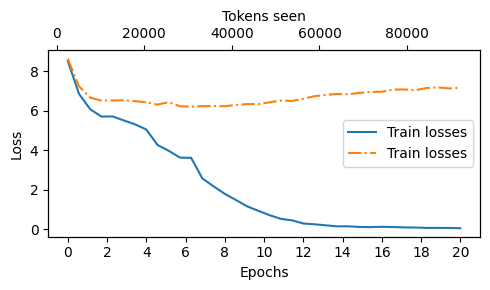

In [ ]:
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_tensor, train_losses, val_losses, tokens_seen):
  fig, ax1 = plt.subplots(figsize=(5, 3))

  ax1.plot(epochs_tensor, train_losses, label='Train losses')
  ax1.plot(epochs_tensor, val_losses, label='Train losses', linestyle='-.')
  ax1.set_xlabel('Epochs')
  ax1.set_ylabel('Loss')
  ax1.legend(loc='center right')
  ax1.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=20)) # No decimal values on x axis

  ax2 = ax1.twiny()
  ax2.plot(tokens_seen, train_losses, label='Train losses', alpha=0)
  ax2.set_xlabel('Tokens seen')

  fig.tight_layout()
  plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, train_losses, val_losses, tokens_seen)

## Load model weights from saved checkpoint

In [ ]:
# Load model weights from saved .pth
!pip install -q gdown
import gdown

file_id = "1CNURoen_16AlpGyEgdcEjvtCBVVLYYHA"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "model_and_optimizer.pth", quiet=False)


Downloading...
From (original): https://drive.google.com/uc?id=1CNURoen_16AlpGyEgdcEjvtCBVVLYYHA
From (redirected): https://drive.google.com/uc?id=1CNURoen_16AlpGyEgdcEjvtCBVVLYYHA&confirm=t&uuid=ed4cad14-e2e3-4935-920a-1c0aabe62185
To: /content/model_and_optimizer.pth
100%|██████████| 1.95G/1.95G [00:22<00:00, 87.9MB/s]


'model_and_optimizer.pth'

In [ ]:
checkpoint = torch.load("model_and_optimizer.pth", map_location="cpu")
model = GPTModel(GPT_CONFIG_124M)

model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")
input_str = "Every effort moves you"
model.eval()
token_ids = generate_text_simple(
    text_to_token_ids(input_str, tokenizer),
    model,
    context_length=GPT_CONFIG_124M["context_length"],
    device=device,
    max_tokens=50
)

print(f"Output: {token_ids_to_text(token_ids, tokenizer)}")

Output: Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"

He laughed again, and threw back his head to look up at the sketch of the donkey. "There were days when I


### Different decoding strategies


*   Greedy decoding -> already using `torch.argmax`
*   Temperature Scaling
*   Top k sampling



In [ ]:
# Toy example for Temperature scaling

vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8
}

inverse_vocab = {v:k for k,v in vocab.items()}

next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probs = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probs, dim=0).item() # GREEDY DECODING (6.75)
inverse_vocab[next_token_id]

'forward'

In [ ]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probs, num_samples=1).item()
inverse_vocab[next_token_id]

'forward'

In [ ]:
from collections import defaultdict
freq_dict = defaultdict(int)

for _ in range(1_000):
  next_token_id = torch.multinomial(probs, num_samples=1).item()
  freq_dict[inverse_vocab[next_token_id]] += 1

for i, k in enumerate(vocab):
  print(f"{k} : {freq_dict[k]}    ({probs[i]:.5f})")


# Means `forward` will be picked more from the probability distribution

closer : 48    (0.06091)
every : 0    (0.00163)
effort : 0    (0.00010)
forward : 581    (0.57212)
inches : 7    (0.00342)
moves : 0    (0.00013)
pizza : 1    (0.00010)
toward : 360    (0.35758)
you : 3    (0.00401)


In [ ]:
# Temperature scaling

def softmax_with_temperature_scaling(logits, temperature=1):
  scaled_logits = logits/temperature
  probs = torch.softmax(scaled_logits, dim=-1)
  return probs

low_temp_probs = softmax_with_temperature_scaling(next_token_logits, 0.2)
high_temp_probs = softmax_with_temperature_scaling(next_token_logits, 20)

low_temp_next_tokens = []
high_temp_next_tokens = []

for _ in range(10):
  next_token_id = torch.multinomial(low_temp_probs, num_samples=1).item()
  low_temp_next_tokens.append(inverse_vocab[next_token_id])

  next_token_id = torch.multinomial(high_temp_probs, num_samples=1).item()
  high_temp_next_tokens.append(inverse_vocab[next_token_id])

print(f"Low temp: {low_temp_next_tokens}")
print(f"High temp: {high_temp_next_tokens}")

Low temp: ['forward', 'forward', 'forward', 'forward', 'forward', 'forward', 'forward', 'toward', 'forward', 'forward']
High temp: ['pizza', 'toward', 'inches', 'you', 'forward', 'toward', 'you', 'you', 'toward', 'forward']


In [ ]:
# Top-k sampling

topk = torch.topk(next_token_logits, k=3)
print(topk, topk.values[-1])
next_token_logits[next_token_logits < topk.values[-1]] = -torch.inf
print(next_token_logits)
probs = torch.softmax(next_token_logits, dim=0)
probs

torch.return_types.topk(
values=tensor([6.7500, 6.2800, 4.5100]),
indices=tensor([3, 7, 0])) tensor(4.5100)
tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])

In [ ]:
low_temp_probs = softmax_with_temperature_scaling(next_token_logits, 0.2)
high_temp_probs = softmax_with_temperature_scaling(next_token_logits, 20)

low_temp_next_tokens = []
high_temp_next_tokens = []

for _ in range(10):
  next_token_id = torch.multinomial(low_temp_probs, num_samples=1).item()
  low_temp_next_tokens.append(inverse_vocab[next_token_id])

  next_token_id = torch.multinomial(high_temp_probs, num_samples=1).item()
  high_temp_next_tokens.append(inverse_vocab[next_token_id])

print(f"Low temp: {low_temp_next_tokens}")
print(f"High temp: {high_temp_next_tokens}")

Low temp: ['forward', 'forward', 'forward', 'forward', 'forward', 'forward', 'forward', 'forward', 'forward', 'forward']
High temp: ['forward', 'closer', 'toward', 'forward', 'forward', 'forward', 'forward', 'closer', 'toward', 'forward']


In [ ]:
def generate_text_temperature_topk(
    input_batch,
    model,
    context_length,
    device,
    max_tokens=50,
    temperature=None,
    topk = None
):
  for _ in range(max_tokens):
    input_batch = input_batch[:, -context_length:]
    input_batch = input_batch.to(device)
    model = model.to(device)
    with torch.no_grad():
      logits = model(input_batch)

    logits = logits[:,-1,:]
    if topk is not None:
      logits[logits < torch.topk(logits.view(-1), topk).values[-1]] = -torch.inf

    if temperature is not None:
      logits = logits/temperature

    probs = torch.softmax(logits, dim=-1, )
    next_token_id = torch.multinomial(probs, num_samples=1)
    input_batch = torch.cat([input_batch, next_token_id], dim=1)

  return token_ids_to_text(input_batch, tokenizer)


generate_text_temperature_topk(
    text_to_token_ids("Every effort moves you", tokenizer),
    model,
    GPT_CONFIG_124M["context_length"],
    device,
    20,
    temperature=12,
    topk=100
)


"Every effort moves you paint she up easter never public't she were When down their thought eyes smile theYes about Victor"

### Loading pretrained weights from OpenAI

In [12]:
import urllib.request

url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/refs/heads/main/ch05/01_main-chapter-code/gpt_download.py"
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7cac8186ede0>)

In [14]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 182kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:01<00:00, 567kiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 227kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [03:23<00:00, 2.45MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 12.4MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:01<00:00, 305kiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 372kiB/s]


In [101]:
print(f"Settings: {settings}")
print(f"Params: {params.keys()}")

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Params: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [18]:
params["wte"].shape, params["wte"]

((50257, 768),
 array([[-0.11010301, -0.03926672,  0.03310751, ..., -0.1363697 ,
          0.01506208,  0.04531523],
        [ 0.04034033, -0.04861503,  0.04624869, ...,  0.08605453,
          0.00253983,  0.04318958],
        [-0.12746179,  0.04793796,  0.18410145, ...,  0.08991534,
         -0.12972379, -0.08785918],
        ...,
        [-0.04453601, -0.05483596,  0.01225674, ...,  0.10435229,
          0.09783269, -0.06952604],
        [ 0.1860082 ,  0.01665728,  0.04611587, ..., -0.09625227,
          0.07847701, -0.02245961],
        [ 0.05135201, -0.02768905,  0.0499369 , ...,  0.00704835,
          0.15519823,  0.12067825]], dtype=float32))

In [41]:
def assign(left, right):

  if left.shape != right.shape:
    raise ValueError(f"Shape mismatch {left.shape} {right.shape}")

  return torch.nn.Parameter(torch.tensor(right))

In [50]:
params.keys(),params["g"].shape, params["b"].shape, params["wte"].shape, model.out_head.weight.shape

(dict_keys(['blocks', 'b', 'g', 'wpe', 'wte']),
 (768,),
 (768,),
 (50257, 768),
 torch.Size([50257, 768]),
 dict_keys(['attn', 'ln_1', 'ln_2', 'mlp']))

In [90]:
block_0 = params["blocks"][0]
print(block_0.keys())
print("Attn", block_0["attn"].keys(), block_0["attn"]["c_attn"].keys(), block_0["attn"]["c_proj"].keys())
print("LN1", block_0["ln_1"].keys())
print("LN2", block_0["ln_2"].keys())
print("MLP", block_0["mlp"].keys(), block_0["mlp"]["c_fc"].keys(), block_0["mlp"]["c_proj"].keys())

print(params["blocks"][0]["attn"]["c_attn"]["b"].shape)
print(block_0["attn"]["c_attn"]["w"].shape, 768*3, model.transformer_blocks[0].attn_block.W_query.weight.shape)
print(block_0["attn"]["c_attn"]["b"].shape)
print(block_0["ln_1"]["g"].shape)
print(params["wte"].shape, model.out_head.weight.shape)
print(model.transformer_blocks[0].ffwd.layers[0].weight.shape, params["blocks"][0]["mlp"]["c_fc"]["w"].shape)
print(model.transformer_blocks[0].ffwd.layers[0].bias.shape, params["blocks"][0]["mlp"]["c_fc"]["b"].shape)
print(model.transformer_blocks[0].attn_block.projection.weight.shape, params["blocks"][0]["attn"]["c_proj"]["w"].shape)
print(len(params["blocks"]), len(model.transformer_blocks))

dict_keys(['attn', 'ln_1', 'ln_2', 'mlp'])
Attn dict_keys(['c_attn', 'c_proj']) dict_keys(['b', 'w']) dict_keys(['b', 'w'])
LN1 dict_keys(['b', 'g'])
LN2 dict_keys(['b', 'g'])
MLP dict_keys(['c_fc', 'c_proj']) dict_keys(['b', 'w']) dict_keys(['b', 'w'])
(2304,)
(768, 2304) 2304 torch.Size([768, 768])
(2304,)
(768,)
(50257, 768) torch.Size([50257, 768])
torch.Size([3072, 768]) (768, 3072)
torch.Size([3072]) (3072,)
torch.Size([768, 768]) (768, 768)
12 12


In [114]:
def load_openai_weights(model, params):
  #print(f"Before: {model.token_embedding.weight}")
  model.token_embedding.weight = assign(model.token_embedding.weight, params["wte"])
  #print(f"After: {model.token_embedding.weight}")
  model.pos_embedding.weight = assign(model.pos_embedding.weight, params["wpe"])


  for idx in range(len(model.transformer_blocks)):

    # Layer Norm 1
    model.transformer_blocks[idx].layer_norm1.scale = assign(
        model.transformer_blocks[idx].layer_norm1.scale,
        params["blocks"][idx]["ln_1"]["g"]
    )
    model.transformer_blocks[idx].layer_norm1.shift = assign(
        model.transformer_blocks[idx].layer_norm1.shift,
        params["blocks"][idx]["ln_1"]["b"]
    )

    # Attention
    W_Q, W_K, W_V = np.split(params["blocks"][idx]["attn"]["c_attn"]["w"], 3, axis=-1)
    B_Q, B_K, B_V = np.split(params["blocks"][idx]["attn"]["c_attn"]["b"], 3, axis=-1)

    model.transformer_blocks[idx].attn_block.W_query.weight = assign(
        model.transformer_blocks[idx].attn_block.W_query.weight,
        W_Q.T
    )
    model.transformer_blocks[idx].attn_block.W_query.bias = assign(
        model.transformer_blocks[idx].attn_block.W_query.bias,
        B_Q.T
    )
    model.transformer_blocks[idx].attn_block.W_key.weight = assign(
        model.transformer_blocks[idx].attn_block.W_key.weight,
        W_K.T
    )
    model.transformer_blocks[idx].attn_block.W_key.bias = assign(
        model.transformer_blocks[idx].attn_block.W_key.bias,
        B_K
    )
    model.transformer_blocks[idx].attn_block.W_value.weight = assign(
        model.transformer_blocks[idx].attn_block.W_value.weight,
        W_V.T
    )
    model.transformer_blocks[idx].attn_block.W_value.bias = assign(
        model.transformer_blocks[idx].attn_block.W_value.bias,
        B_V
    )

    model.transformer_blocks[idx].attn_block.projection.weight = assign(
        model.transformer_blocks[idx].attn_block.projection.weight,
        params["blocks"][idx]["attn"]["c_proj"]["w"].T
    )
    model.transformer_blocks[idx].attn_block.projection.bias = assign(
        model.transformer_blocks[idx].attn_block.projection.bias,
        params["blocks"][idx]["attn"]["c_proj"]["b"]
    )

    # Layer Norm 2
    model.transformer_blocks[idx].layer_norm2.scale = assign(
        model.transformer_blocks[idx].layer_norm2.scale,
        params["blocks"][idx]["ln_2"]["g"]
    )
    model.transformer_blocks[idx].layer_norm2.shift = assign(
        model.transformer_blocks[idx].layer_norm2.shift,
        params["blocks"][idx]["ln_2"]["b"]
    )

    # Feed Forward
    model.transformer_blocks[idx].ffwd.layers[0].weight = assign(
        model.transformer_blocks[idx].ffwd.layers[0].weight,
        params["blocks"][idx]["mlp"]["c_fc"]["w"].T
    )
    model.transformer_blocks[idx].ffwd.layers[0].bias = assign(
        model.transformer_blocks[idx].ffwd.layers[0].bias,
        params["blocks"][idx]["mlp"]["c_fc"]["b"]
    )
    model.transformer_blocks[idx].ffwd.layers[2].weight = assign(
        model.transformer_blocks[idx].ffwd.layers[2].weight,
        params["blocks"][idx]["mlp"]["c_proj"]["w"].T
    )
    model.transformer_blocks[idx].ffwd.layers[2].bias = assign(
        model.transformer_blocks[idx].ffwd.layers[2].bias,
        params["blocks"][idx]["mlp"]["c_proj"]["b"]
    )


  # Final Layer Norm
  model.layer_norm.scale = assign(
      model.layer_norm.scale,
      params["g"]
  )
  model.layer_norm.shift = assign(
      model.layer_norm.shift,
      params["b"]
  )

  # Out head
  model.out_head.weight = assign(
      model.out_head.weight,
      params["wte"] # Reuses weights from token embedding layer
  )

In [115]:
GPT_CONFIG_124M.update({"context_length": 1024, "qkv_bias": True})
model = GPTModel(GPT_CONFIG_124M)
print(GPT_CONFIG_124M)

load_openai_weights(model, params)

{'vocab_size': 50257, 'context_length': 1024, 'emb_dim': 768, 'n_heads': 12, 'n_layers': 12, 'drop_rate': 0.1, 'qkv_bias': True}


In [116]:
def generate_text_temperature_topk(
    input_batch,
    model,
    context_length,
    device,
    max_tokens=50,
    temperature=None,
    topk = None
):
  for _ in range(max_tokens):
    input_batch = input_batch[:, -context_length:]
    input_batch = input_batch.to(device)
    model = model.to(device)
    with torch.no_grad():
      logits = model(input_batch)

    logits = logits[:,-1,:]
    if topk is not None:
      logits[logits < torch.topk(logits.view(-1), topk).values[-1]] = -torch.inf

    if temperature is not None:
      logits = logits/temperature

    probs = torch.softmax(logits, dim=-1)
    next_token_id = torch.multinomial(probs, num_samples=1)
    input_batch = torch.cat([input_batch, next_token_id], dim=1)

  return token_ids_to_text(input_batch, tokenizer)

tokenizer = tiktoken.get_encoding("gpt2")

In [117]:
torch.manual_seed(123)
model.eval()
generate_text_temperature_topk(
    text_to_token_ids("Every effort moves you", tokenizer).to(device),
    model,
    GPT_CONFIG_124M["context_length"],
    device,
    25,
    temperature=1.5,
    topk=50
)

'Every effort moves you toward finding an ideal new way to practice something!\n\nWhat makes us want to be on top of that?\n\n'

### EXERCISE 5.5

In [125]:
len(val_dataloader)

0

In [128]:
# Training and validation loss after loading OpenAI weights on "The Verdict dataset"

model.to(device)
model.eval()

with torch.no_grad():
  train_loss = calc_loss_dataloader(train_dataloader, model, device)
  val_loss = calc_loss_dataloader(val_dataloader, model, device)

print(f"Train loss: {train_loss} Val loss: {val_loss}")

# Train loss: 3.7547490066952176 Val loss: 3.5596206188201904

Train loss: 3.7547490066952176 Val loss: 3.5596206188201904
